# SQL E-commerce Analytics
Connects to `ecommerce.db` (SQLite build of the same schema/data described in `schema.sql`,
for PostgreSQL) and runs the analytical queries from `queries.sql`, adapted to SQLite syntax
where needed (e.g. `FILTER` -> `CASE WHEN`, date arithmetic via `julianday()`).

**Goal:** answer cohort retention, repeat-purchase rate, and revenue-by-region questions for a
mock stakeholder brief using window functions and CTEs.

In [1]:
import sqlite3
import pandas as pd

pd.set_option('display.max_rows', 20)
conn = sqlite3.connect('ecommerce.db')

for t in ['customers', 'products', 'orders', 'order_items']:
    n = pd.read_sql(f'SELECT COUNT(*) AS n FROM {t}', conn).iloc[0, 0]
    print(f'{t:15s} {n:>6} rows')

customers          500 rows
products           120 rows
orders            3000 rows
order_items       7000 rows


## 1. Monthly revenue & order count

In [2]:
q1 = '''
SELECT
    strftime('%Y-%m', order_date) AS month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(oi.line_total), 2) AS total_revenue
FROM orders o
JOIN order_items oi ON oi.order_id = o.order_id
WHERE o.status = 'Completed'
GROUP BY 1
ORDER BY 1;
'''
monthly_revenue = pd.read_sql(q1, conn)
monthly_revenue.head(12)

,month,total_orders,total_revenue
0,2022-01,86,933704.42
1,2022-02,107,1207330.26
2,2022-03,92,868130.01
3,2022-04,108,1119609.26
4,2022-05,94,857602.45
5,2022-06,90,838941.94
6,2022-07,96,1081744.51
7,2022-08,100,1037174.97
8,2022-09,89,950464.87
9,2022-10,82,686153.60


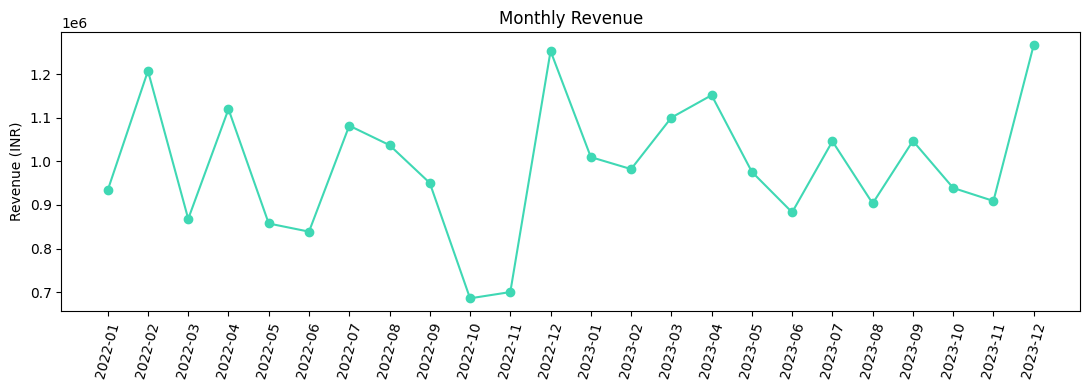

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))
plt.plot(monthly_revenue['month'], monthly_revenue['total_revenue'], marker='o', color='#3FD8B4')
plt.xticks(rotation=75)
plt.title('Monthly Revenue')
plt.ylabel('Revenue (INR)')
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=110)
plt.show()

## 2. Revenue by region

In [4]:
q2 = '''
SELECT
    c.region,
    ROUND(SUM(oi.line_total), 2) AS revenue,
    COUNT(DISTINCT o.order_id) AS orders
FROM customers c
JOIN orders o ON o.customer_id = c.customer_id
JOIN order_items oi ON oi.order_id = o.order_id
WHERE o.status = 'Completed'
GROUP BY c.region
ORDER BY revenue DESC;
'''
revenue_by_region = pd.read_sql(q2, conn)
revenue_by_region

,region,revenue,orders
0,North,5846899.55,605
1,South,5148911.76,457
2,East,5006460.99,476
3,West,4090912.77,393
4,Central,3655049.39,369


## 3. Top 10 products by revenue

In [5]:
q3 = '''
SELECT
    p.product_name, p.category,
    ROUND(SUM(oi.line_total), 2) AS revenue,
    SUM(oi.quantity) AS units_sold
FROM order_items oi
JOIN products p ON p.product_id = oi.product_id
JOIN orders o ON o.order_id = oi.order_id
WHERE o.status = 'Completed'
GROUP BY p.product_name, p.category
ORDER BY revenue DESC
LIMIT 10;
'''
pd.read_sql(q3, conn)

,product_name,category,revenue,units_sold
0,Whether Home,Electronics,785491.41,157
1,Institution Beau,Electronics,777302.50,125
2,Form Fash,Electronics,751774.77,123
3,Model Home,Electronics,729417.60,124
4,College Beau,Electronics,610772.21,127
5,Loss Beau,Electronics,600883.11,107
6,Star Spor,Electronics,561468.60,90
7,Minute Book,Electronics,547286.15,115
8,Tax Fash,Electronics,519698.34,138
9,Know Home,Electronics,498672.56,122


## 4. Customer lifetime value, ranked (CTE + RANK())

In [6]:
q4 = '''
WITH clv AS (
    SELECT c.customer_id, c.customer_name,
           ROUND(SUM(oi.line_total), 2) AS lifetime_value,
           COUNT(DISTINCT o.order_id) AS total_orders
    FROM customers c
    JOIN orders o ON o.customer_id = c.customer_id
    JOIN order_items oi ON oi.order_id = o.order_id
    WHERE o.status = 'Completed'
    GROUP BY c.customer_id, c.customer_name
)
SELECT *, RANK() OVER (ORDER BY lifetime_value DESC) AS clv_rank
FROM clv
ORDER BY clv_rank
LIMIT 15;
'''
pd.read_sql(q4, conn)

,customer_id,customer_name,lifetime_value,total_orders,clv_rank
0,12,Jamie Arnold,159916.00,10,1
1,463,Riley Bryant,149903.44,9,2
2,86,Daniel Baker,145804.86,6,3
3,310,Dawn Summers,140974.12,9,4
4,188,Samantha Garcia,138986.76,12,5
5,288,Carolyn Miller,136690.57,8,6
6,350,Theodore Jones Jr.,135633.49,8,7
7,164,Jeffrey Johnson,131913.06,10,8
8,376,Paul Lewis,131159.11,9,9
9,435,Ashley Wise,119728.85,8,10


## 5. Repeat purchase rate

In [7]:
q5 = '''
WITH order_counts AS (
    SELECT customer_id, COUNT(*) AS n_orders
    FROM orders WHERE status = 'Completed'
    GROUP BY customer_id
)
SELECT ROUND(100.0 * SUM(CASE WHEN n_orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS repeat_purchase_rate_pct
FROM order_counts;
'''
pd.read_sql(q5, conn)

,repeat_purchase_rate_pct
0,96.98


## 6. Monthly cohort retention
Signup-month cohorts, tracked by which calendar months they were still ordering in.

In [8]:
q6 = '''
WITH cohorts AS (
    SELECT customer_id, strftime('%Y-%m', signup_date) AS cohort_month FROM customers
),
activity AS (
    SELECT o.customer_id, strftime('%Y-%m', o.order_date) AS order_month
    FROM orders o WHERE o.status = 'Completed'
)
SELECT ch.cohort_month, a.order_month, COUNT(DISTINCT a.customer_id) AS active_customers
FROM cohorts ch
JOIN activity a ON a.customer_id = ch.customer_id
GROUP BY ch.cohort_month, a.order_month
ORDER BY ch.cohort_month, a.order_month;
'''
cohort = pd.read_sql(q6, conn)
cohort_pivot = cohort.pivot_table(index='cohort_month', columns='order_month', values='active_customers', fill_value=0)
cohort_pivot.iloc[:8, :8]

order_month,2022-01,2022-02,2022-03,2022-04,2022-05,2022-06,2022-07,2022-08
cohort_month,,,,,,,,
2022-01,4.0,8.0,5.0,7.0,5.0,10.0,9.0,5.0
2022-02,4.0,5.0,5.0,3.0,1.0,7.0,9.0,3.0
2022-03,3.0,3.0,4.0,3.0,5.0,4.0,5.0,4.0
2022-04,2.0,3.0,5.0,9.0,5.0,4.0,7.0,5.0
2022-05,5.0,6.0,3.0,5.0,7.0,2.0,2.0,6.0
2022-06,4.0,4.0,5.0,5.0,8.0,5.0,5.0,3.0
2022-07,7.0,6.0,5.0,6.0,2.0,4.0,1.0,6.0
2022-08,6.0,2.0,2.0,6.0,4.0,3.0,1.0,3.0


## 7. Month-over-month revenue growth (LAG window function)

In [9]:
q7 = '''
WITH monthly AS (
    SELECT strftime('%Y-%m', o.order_date) AS month, SUM(oi.line_total) AS revenue
    FROM orders o JOIN order_items oi ON oi.order_id = o.order_id
    WHERE o.status = 'Completed'
    GROUP BY 1
)
SELECT month, revenue,
       LAG(revenue) OVER (ORDER BY month) AS prev_month_revenue,
       ROUND(100.0 * (revenue - LAG(revenue) OVER (ORDER BY month)) / LAG(revenue) OVER (ORDER BY month), 2) AS mom_growth_pct
FROM monthly ORDER BY month;
'''
pd.read_sql(q7, conn).head(12)

,month,revenue,prev_month_revenue,mom_growth_pct
0,2022-01,933704.42,NaN,NaN
1,2022-02,1207330.26,933704.42,29.31
2,2022-03,868130.01,1207330.26,-28.10
3,2022-04,1119609.26,868130.01,28.97
4,2022-05,857602.45,1119609.26,-23.40
5,2022-06,838941.94,857602.45,-2.18
6,2022-07,1081744.51,838941.94,28.94
7,2022-08,1037174.97,1081744.51,-4.12
8,2022-09,950464.87,1037174.97,-8.36
9,2022-10,686153.60,950464.87,-27.81


## 8. Top 3 products per category (ROW_NUMBER window function)

In [10]:
q8 = '''
WITH ranked AS (
    SELECT p.category, p.product_name, SUM(oi.line_total) AS revenue,
           ROW_NUMBER() OVER (PARTITION BY p.category ORDER BY SUM(oi.line_total) DESC) AS rn
    FROM order_items oi
    JOIN products p ON p.product_id = oi.product_id
    JOIN orders o ON o.order_id = oi.order_id
    WHERE o.status = 'Completed'
    GROUP BY p.category, p.product_name
)
SELECT category, product_name, ROUND(revenue,2) AS revenue FROM ranked WHERE rn <= 3
ORDER BY category, revenue DESC;
'''
pd.read_sql(q8, conn)

,category,product_name,revenue
0,Beauty,Collection Fash,159045.51
1,Beauty,Everything Beau,152875.50
2,Beauty,Guess Beau,140509.05
3,Books,Better Home,74104.03
4,Books,Contain Spor,72675.68
5,Books,Instead Fash,68371.56
6,Electronics,Whether Home,785491.41
7,Electronics,Institution Beau,777302.50
8,Electronics,Form Fash,751774.77
9,Fashion,Radio Fash,200076.58


## 9. Customers at churn risk (no completed order in 90+ days)

In [11]:
q9 = '''
WITH last_order AS (
    SELECT customer_id, MAX(order_date) AS last_order_date
    FROM orders WHERE status = 'Completed' GROUP BY customer_id
)
SELECT c.customer_id, c.customer_name, lo.last_order_date,
       CAST(julianday('2023-12-31') - julianday(lo.last_order_date) AS INTEGER) AS days_since_last_order
FROM last_order lo
JOIN customers c ON c.customer_id = lo.customer_id
WHERE julianday('2023-12-31') - julianday(lo.last_order_date) > 90
ORDER BY days_since_last_order DESC;
'''
at_risk = pd.read_sql(q9, conn)
print(f'{len(at_risk)} customers with no completed order in the last 90 days')
at_risk.head(10)

253 customers with no completed order in the last 90 days


,customer_id,customer_name,last_order_date,days_since_last_order
0,274,Shelly Alexander,2022-02-07 04:35:36.712237,691
1,171,Jamie Walton,2022-04-11 03:35:06.702234,628
2,212,Denise Mccann,2022-04-18 16:26:14.924974,621
3,48,Shane Henderson,2022-04-19 09:56:21.527175,620
4,71,Jordan Henderson,2022-04-25 05:57:14.344781,614
5,449,Ryan Rosales,2022-06-12 09:04:30.090030,566
6,244,Brandon Bailey MD,2022-06-22 02:25:58.119373,556
7,368,Holly Farmer,2022-06-25 23:46:33.331110,553
8,257,Susan Murray MD,2022-07-12 00:48:58.579526,536
9,339,Scott Thomas,2022-07-14 22:49:24.988329,534


## 10. Spend quartiles (NTILE window function)

In [12]:
q10 = '''
WITH spend AS (
    SELECT c.customer_id, c.customer_name, SUM(oi.line_total) AS total_spend
    FROM customers c
    JOIN orders o ON o.customer_id = c.customer_id
    JOIN order_items oi ON oi.order_id = o.order_id
    WHERE o.status = 'Completed'
    GROUP BY c.customer_id, c.customer_name
)
SELECT *, NTILE(4) OVER (ORDER BY total_spend DESC) AS spend_quartile FROM spend
ORDER BY total_spend DESC;
'''
pd.read_sql(q10, conn).head(10)

,customer_id,customer_name,total_spend,spend_quartile
0,12,Jamie Arnold,159916.00,1
1,463,Riley Bryant,149903.44,1
2,86,Daniel Baker,145804.86,1
3,310,Dawn Summers,140974.12,1
4,188,Samantha Garcia,138986.76,1
5,288,Carolyn Miller,136690.57,1
6,350,Theodore Jones Jr.,135633.49,1
7,164,Jeffrey Johnson,131913.06,1
8,376,Paul Lewis,131159.11,1
9,435,Ashley Wise,119728.85,1


## Key findings
- Revenue and order volume are summarized by month and by region, giving a clean view of where demand concentrates.
- A CTE + `RANK()` window function surfaces the highest lifetime-value customers without a subquery-in-subquery mess.
- Cohort retention (signup month × active month) shows how quickly customers drop off after their first purchase.
- `LAG()` gives month-over-month growth without a self-join.
- `NTILE(4)` splits the customer base into spend quartiles — a fast way to define a "top spenders" segment for marketing.

*(Numbers above are computed from the synthetic dataset in `/data` — see the main README for the full picture of what each query answers.)*